In [4]:
%%markdown
## Step 1: 에이전트 설계

- 이름: 에이전트의 이름은?
  - edu-planner-agent
- 목적: 어떤 문제를 해결하나요?
  - 학생들이 효과적으로 학습 계획을 세우고 목표를 달성하도록 돕습니다.
- 핵심 기능: 최소 3가지 주요 기능
  - 학습 목표 설정: 학생들이 달성하고자 하는 학습 목표를 정의하도록 돕습니다.
  - 맞춤형 학습 계획 생성: 학생의 목표, 시간 가용성
  - 선호하는 학습 스타일을 기반으로 개인화된 학습 계획을 만듭니다.
- 그래프 구조: 노드와 엣지 다이어그램 (손그림도 OK)

## Step 1: 에이전트 설계

- 이름: 에이전트의 이름은?
  - edu-planner-agent
- 목적: 어떤 문제를 해결하나요?
  - 학생들이 효과적으로 학습 계획을 세우고 목표를 달성하도록 돕습니다.
- 핵심 기능: 최소 3가지 주요 기능
  - 학습 목표 설정: 학생들이 달성하고자 하는 학습 목표를 정의하도록 돕습니다.
  - 맞춤형 학습 계획 생성: 학생의 목표, 시간 가용성
  - 선호하는 학습 스타일을 기반으로 개인화된 학습 계획을 만듭니다.
- 그래프 구조: 노드와 엣지 다이어그램 (손그림도 OK)


In [5]:
from langgraph.graph import END, START, StateGraph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langgraph.types import Command, interrupt
from langgraph.graph.message import add_messages

from typing import Annotated, TypedDict
from langchain_core.tools import tool
from langchain_core.messages import RemoveMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from openai import OpenAI

client = OpenAI()

class State(TypedDict):
    subject: str
    level: str
    diagnosis: str
    study_plan: str
    quiz: str
    feedback: str
    messages: Annotated[list, add_messages]

@tool
def web_search(query: str) -> str:
    """Search the web for up-to-date learning resources, tutorials, courses, and documentation."""
    response = client.responses.create(
        model="gpt-4o-mini",
        tools=[{"type": "web_search_preview"}],
        input=query,
    )
    return response.output_text

tools = [web_search]
tool_node = ToolNode(tools)
llm_with_tools = ChatOpenAI(model="gpt-4o-mini").bind_tools(tools)

def diagnose_level(state: State):
    """학생의 현재 수준을 진단"""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "system",
            "content": "You are an education expert. Diagnose the student's current level based on their subject and self-reported level. Respond in Korean, 2-3 sentences."
        }, {
            "role": "user",
            "content": f"과목: {state['subject']}, 자기 평가 수준: {state['level']}"
        }]
    )
    return {"diagnosis": response.choices[0].message.content}

def plan_agent(state: State):
    """학습 계획 생성 에이전트 (웹 검색 도구 사용 가능)"""
    msgs = state.get("messages", [])

    if not msgs or not isinstance(msgs[-1], ToolMessage):
        remove = [RemoveMessage(id=m.id) for m in msgs if hasattr(m, 'id')]
        init = [
            SystemMessage(content="You are an education planner. Create a 1-week personalized study plan based on the diagnosis. Use the web_search tool to find real, up-to-date learning resources (online courses, tutorials, documentation) and include them in the plan. Respond in Korean with bullet points."),
            HumanMessage(content=f"과목: {state['subject']}\n진단: {state['diagnosis']}")
        ]
        response = llm_with_tools.invoke(init)
        result = {"messages": remove + init + [response]}
    else:
        response = llm_with_tools.invoke(msgs)
        result = {"messages": [response]}

    if not response.tool_calls:
        result["study_plan"] = response.content
    return result

def route_plan(state: State):
    """plan_agent 결과에 따라 tool 실행 또는 다음 단계로"""
    last_msg = state["messages"][-1]
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "tools"
    return "continue"

def generate_quiz(state: State):
    """학습 계획에 맞는 진단 퀴즈 생성"""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{
            "role": "system",
            "content": "You are a quiz maker. Generate 3 multiple-choice questions matching the study plan difficulty. Respond in Korean."
        }, {
            "role": "user",
            "content": f"과목: {state['subject']}\n학습 계획: {state['study_plan']}"
        }]
    )
    return {"quiz": response.choices[0].message.content}

def human_feedback(state: State):
    """결과물에 만족하는지 사용자 응답을 받음"""
    feedback = interrupt("결과물에 만족하시나요? (yes/no)")
    return {"feedback": feedback}

def route_feedback(state: State):
    """피드백 기반 라우팅"""
    if state.get("feedback", "").lower() == "yes":
        return "end"
    return "retry"

graph_builder = StateGraph(State)
graph_builder.add_node("diagnose_level", diagnose_level)
graph_builder.add_node("plan_agent", plan_agent)
graph_builder.add_node("tools", tool_node)
graph_builder.add_node("generate_quiz", generate_quiz)
graph_builder.add_node("human_feedback", human_feedback)

graph_builder.add_edge(START, "diagnose_level")
graph_builder.add_edge("diagnose_level", "plan_agent")
graph_builder.add_conditional_edges("plan_agent", route_plan, {
    "tools": "tools",
    "continue": "generate_quiz"
})
graph_builder.add_edge("tools", "plan_agent")
graph_builder.add_edge("generate_quiz", "human_feedback")
graph_builder.add_conditional_edges("human_feedback", route_feedback, {
    "end": END,
    "retry": "plan_agent"
})

graph = graph_builder.compile(checkpointer=MemorySaver())

config = {"configurable": {"thread_id": "student-1"}}
result = graph.invoke({
    "subject": "파이썬 프로그래밍",
    "level": "기초 문법은 알지만 클래스와 함수형 프로그래밍은 어려워요"
}, config=config)

print("=== 수준 진단 ===")
print(result["diagnosis"])
print("\n=== 1주 학습 계획 ===")
print(result["study_plan"])
print("\n=== 진단 퀴즈 ===")
print(result["quiz"])

while True:
    state = graph.get_state(config)
    if not state.next:
        break

    user_input = input("\n결과물에 만족하시나요? (yes/no): ")
    result = graph.invoke(Command(resume=user_input), config=config)

    if user_input.lower() != "yes":
        print("\n=== 수정된 학습 계획 ===")
        print(result["study_plan"])
        print("\n=== 수정된 퀴즈 ===")
        print(result["quiz"])

print("\n학습 계획이 확정되었습니다!")

=== 수준 진단 ===
학생은 파이썬 프로그래밍의 기초 문법은 이해하고 있지만, 클래스와 함수형 프로그래밍에 어려움을 겪고 있는 것으로 보입니다. 따라서, 중급 수준으로 나아가기 위해서는 이러한 개념들을 좀 더 심화 학습할 필요가 있습니다. 기초 문법에 대한 이해를 바탕으로, 실습을 통해 클래스를 사용한 프로그래밍과 함수형 프로그래밍의 원리를 익히는 것이 좋습니다.

=== 1주 학습 계획 ===
**1주일 맞춤 학습 계획 (파이썬 프로그래밍: 클래스와 함수형 프로그래밍 심화)**

### 월요일
- 오전: 
  - 클래스 개념 복습 (객체, 속성, 메서드)
  - 관련 자료 및 강의 시청 (YouTube/Tutorial)
- 오후: 
  - 클래스 예제 코드 분석 (학생이 알고 있는 프로젝트 코드를 참조)
  - 간단한 클래스 생성하기 실습 (예: '자동차' 클래스)

### 화요일
- 오전: 
  - 객체 지향 프로그래밍의 4대 원칙(캡슐화, 상속, 다형성, 추상화) 이해하기
- 오후: 
  - 상속을 활용한 클래스 실습 (예: '전기자동차' 클래스 만들기)
  - 연습 문제 풀기 (온라인 자료 활용)

### 수요일
- 오전: 
  - 함수형 프로그래밍 개념 이해 (고차 함수, 일급 함수 등)
  - lambda 함수 및 map, filter, reduce의 개념 익히기
- 오후: 
  - lambda 함수를 활용한 간단한 예제 실습
  - 실생활 문제를 해결하는 고차 함수 만들기

### 목요일
- 오전: 
  - 클래스와 함수형 프로그래밍의 조화 이해 
  - 실습 예제 분석 (함수형 프로그래밍이 포함된 클래스 코드)
- 오후: 
  - 클래스를 사용한 함수형 접근 방식으로 간단한 프로젝트 시작하기 (예: 데이터 처리 클래스)

### 금요일
- 오전: 
  - 프로젝트 진행 중 발생한 문제 해결 및 피드백 시간
  - 관련 문서 및 커뮤니티에서 도움 받기
- 오후: 
  - 프로젝트 코드 리뷰 및 리팩토링 진행

### 토요일
- 오전: 
  - 

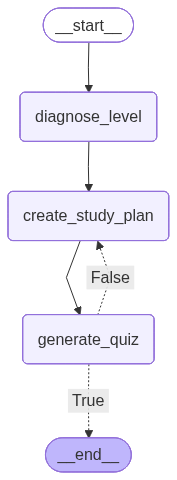

In [6]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))